In [1]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [2]:
project_root = Path.cwd().parent

image_dir = project_root / "data" / "raw" / "Train" / "Rural" / "images_png"
mask_dir = project_root / "data" / "raw" / "Train" / "Rural" / "masks_png"

images = sorted(image_dir.glob("*.png"))
masks = sorted(mask_dir.glob("*.png"))

print("Images:", len(images))
print("Masks:", len(masks))

print("First image:", images[0].name)
print("First mask:", masks[0].name)

Images: 1366
Masks: 1366
First image: 0.png
First mask: 0.png


In [3]:
image = Image.open(images[0])
mask = Image.open(masks[0])

image_np = np.array(image)
mask_np = np.array(mask)

print("Image shape:", image_np.shape)
print("Mask shape:", mask_np.shape)
print("Unique mask values:", np.unique(mask_np))

Image shape: (1024, 1024, 3)
Mask shape: (1024, 1024)
Unique mask values: [1 2 3 4 7]


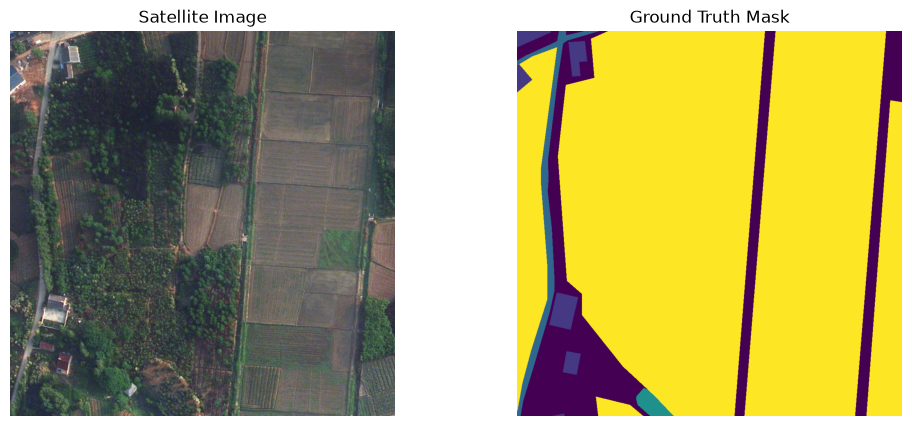

In [4]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_np)
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_np)
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

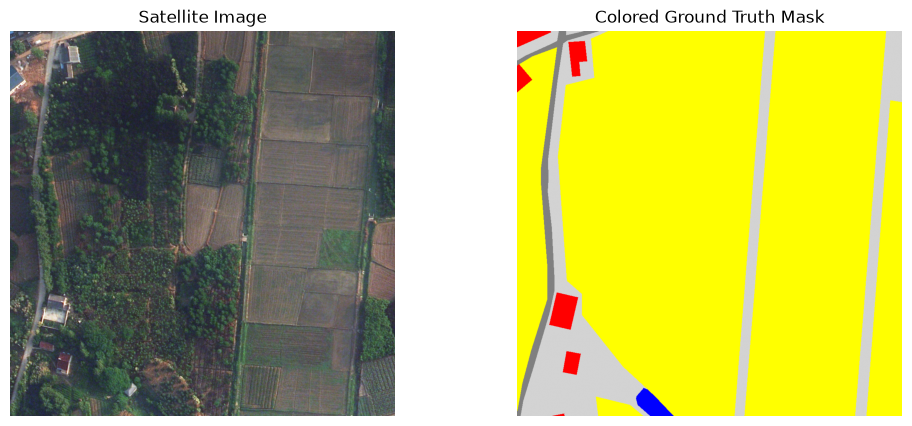

In [5]:
from matplotlib.colors import ListedColormap

class_names = {
    0: "No Data",
    1: "Background",
    2: "Building",
    3: "Road",
    4: "Water",
    5: "Barren",
    6: "Forest",
    7: "Agriculture"
}

colors = [
    "black",      # 0 No Data
    "lightgray",  # 1 Background
    "red",        # 2 Building
    "gray",       # 3 Road
    "blue",       # 4 Water
    "brown",      # 5 Barren
    "green",      # 6 Forest
    "yellow"      # 7 Agriculture
]

cmap = ListedColormap(colors)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_np)
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_np, cmap=cmap, vmin=0, vmax=7)
plt.title("Colored Ground Truth Mask")
plt.axis("off")

plt.show()

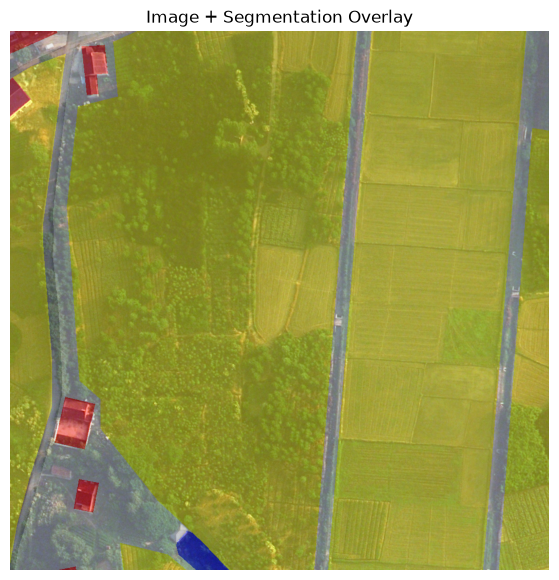

In [6]:
plt.figure(figsize=(7, 7))

plt.imshow(image_np)
plt.imshow(mask_np, cmap=cmap, alpha=0.4, vmin=0, vmax=7)

plt.title("Image + Segmentation Overlay")
plt.axis("off")

plt.show()

In [7]:
unique_classes = np.unique(mask_np)

for class_id in unique_classes:
    print(class_id, "->", class_names[class_id])

1 -> Background
2 -> Building
3 -> Road
4 -> Water
7 -> Agriculture


,Class ID,Class,Pixels,Pixel Coverage (%),Masks Containing Class,Mask Coverage (%)
0,0,No Data,"41,236,648",2.88,192,14.06
1,1,Background,"351,704,076",24.55,1332,97.51
2,2,Building,"36,891,628",2.58,927,67.86
3,3,Road,"27,053,972",1.89,880,64.42
4,4,Water,"119,674,656",8.36,1203,88.07
5,5,Barren,"45,460,577",3.17,512,37.48
6,6,Forest,"317,735,062",22.18,1032,75.55
7,7,Agriculture,"492,598,197",34.39,1005,73.57


Total counted pixels: 1,432,354,816
Expected pixels:      1,432,354,816


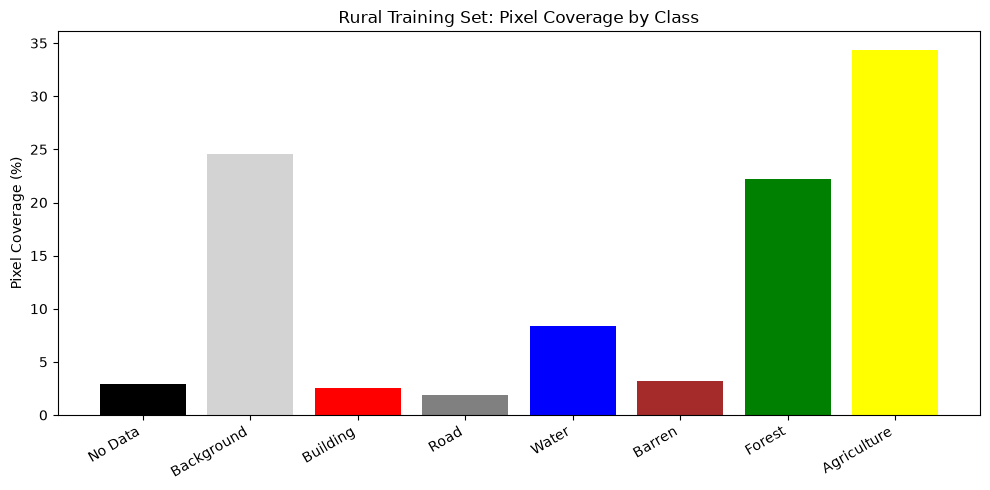

In [8]:
import pandas as pd

class_ids = np.arange(8)
pixel_counts = np.zeros(len(class_ids), dtype=np.int64)
mask_counts = np.zeros(len(class_ids), dtype=np.int64)

for mask_path in masks:
    current_mask = np.array(Image.open(mask_path))
    present_classes = np.unique(current_mask)

    # Stop early if the dataset contains a label without a documented name.
    unknown_classes = set(present_classes) - set(class_names)
    if unknown_classes:
        raise ValueError(f"Unknown class IDs in {mask_path.name}: {unknown_classes}")

    pixel_counts += np.bincount(current_mask.ravel(), minlength=len(class_ids))[:len(class_ids)]
    mask_counts[present_classes] += 1

total_pixels = pixel_counts.sum()
expected_pixels = len(masks) * mask_np.shape[0] * mask_np.shape[1]
assert total_pixels == expected_pixels, (
    f"Counted {total_pixels:,} pixels, but expected {expected_pixels:,}."
)

class_statistics = pd.DataFrame({
    "Class ID": class_ids,
    "Class": [class_names[class_id] for class_id in class_ids],
    "Pixels": pixel_counts,
    "Pixel Coverage (%)": pixel_counts / total_pixels * 100,
    "Masks Containing Class": mask_counts,
    "Mask Coverage (%)": mask_counts / len(masks) * 100,
})

display(class_statistics.style.format({
    "Pixels": "{:,}",
    "Pixel Coverage (%)": "{:.2f}",
    "Mask Coverage (%)": "{:.2f}",
}))

print(f"Total counted pixels: {total_pixels:,}")
print(f"Expected pixels:      {expected_pixels:,}")

plt.figure(figsize=(10, 5))
plt.bar(class_statistics["Class"], class_statistics["Pixel Coverage (%)"], color=colors)
plt.title("Rural Training Set: Pixel Coverage by Class")
plt.ylabel("Pixel Coverage (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()